In [1]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import pymssql 
import scipy


In [3]:
# Connecting to the MS SQL Server database

def get_connection():
    return pymssql.connect(
        server='localhost',
        port='1433',
        user='sa',
        password='Poor@b19',
        database='AQI'
    )

engine = create_engine('mssql+pymssql://', creator=get_connection)

with engine.connect() as conn:
    print(" Connected to MS SQL Server!")

 Connected to MS SQL Server!


In [4]:
df_hist = pd.read_sql("SELECT * FROM [dbo].[air_quality_historical]", engine)

In [5]:
## Fetching the data from the database

df_hist['date'] = pd.to_datetime(df_hist['date'])
df_hist['year'] = df_hist['date'].dt.year
df_hist['month'] = df_hist['date'].dt.month
df_hist['season'] = df_hist['month'].map({12:'Winter',1:'Winter',2:'Winter',3:'Summer',4:'Summer',5:'Summer',
                                  6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Post-Monsoon',10:'Post-Monsoon',11:'Post-Monsoon'})

region_map = {'Delhi':'North','Gurugram':'North','Amritsar':'North','Chandigarh':'North','Lucknow':'North','Jaipur':'North',
    'Patna':'East','Kolkata':'East','Guwahati':'East','Jorapokhar':'East','Brajrajnagar':'East','Talcher':'East',
    'Mumbai':'West','Ahmedabad':'West','Bhopal':'West','Amaravati':'South','Bengaluru':'South','Chennai':'South',
    'Hyderabad':'South','Coimbatore':'South','Kochi':'South','Ernakulam':'South','Thiruvananthapuram':'South',
    'Visakhapatnam':'South','Aizawl':'Northeast','Shillong':'Northeast'}
df_hist['region'] = df_hist['city'].map(region_map)

df_hist['category'] = pd.cut(df_hist['aqi'], bins=[0,50,100,200,300,400,1000], 
                               labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Severe'])

print(f"   Rows    : {len(df_hist):,}")
print(f"   Columns : {df_hist.columns.tolist()}")

   Rows    : 27,246
   Columns : ['city', 'date', 'pm25', 'pm10', 'no', 'no2', 'nox', 'nh3', 'co', 'so2', 'o3', 'benzene', 'toluene', 'xylene', 'aqi', 'aqi_bucket', 'year', 'month', 'season', 'region', 'category']


In [6]:
df_hist.head(10)

,city,date,pm25,pm10,no,no2,nox,nh3,co,so2,...,benzene,toluene,xylene,aqi,aqi_bucket,year,month,season,region,category
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,...,NaN,0.02,NaN,NaN,NaN,2015,1,Winter,West,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,...,3.68,5.50,3.77,NaN,NaN,2015,1,Winter,West,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,...,6.80,16.40,2.25,NaN,NaN,2015,1,Winter,West,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,...,4.43,10.14,1.00,NaN,NaN,2015,1,Winter,West,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,...,7.01,18.89,2.78,NaN,NaN,2015,1,Winter,West,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,...,5.42,10.83,1.93,NaN,NaN,2015,1,Winter,West,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,...,NaN,NaN,NaN,NaN,NaN,2015,1,Winter,West,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,...,NaN,NaN,NaN,NaN,NaN,2015,1,Winter,West,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,...,NaN,NaN,NaN,NaN,NaN,2015,1,Winter,West,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,NaN,NaN,NaN,8.29,...,NaN,NaN,NaN,NaN,NaN,2015,1,Winter,West,NaN


In [7]:
df_hist.info()

<class 'pandas.DataFrame'>
RangeIndex: 27246 entries, 0 to 27245
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   city        27246 non-null  str           
 1   date        27246 non-null  datetime64[us]
 2   pm25        24677 non-null  float64       
 3   pm10        18391 non-null  float64       
 4   no          25949 non-null  float64       
 5   no2         25946 non-null  float64       
 6   nox         24606 non-null  float64       
 7   nh3         19203 non-null  float64       
 8   co          25144 non-null  float64       
 9   so2         25677 non-null  float64       
 10  o3          25509 non-null  float64       
 11  benzene     20106 non-null  float64       
 12  toluene     18629 non-null  float64       
 13  xylene      9675 non-null   float64       
 14  aqi         24834 non-null  float64       
 15  aqi_bucket  24850 non-null  str           
 16  year        27246 non-null  int32

**These are the 26 Unique Cities**

In [8]:
df_hist['city'].unique()

<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str

In [9]:
df_hist[df_hist['city'].str.isnumeric()] 
# there is no column with numeric values in the city column, so this will return an empty dataframe.

,city,date,pm25,pm10,no,no2,nox,nh3,co,so2,...,benzene,toluene,xylene,aqi,aqi_bucket,year,month,season,region,category


In [10]:
df_recent = pd.read_sql("SELECT * FROM air_quality_recent", engine)

In [11]:
df_recent.head(10)

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status
0,2025-04-08,West Bengal,Siliguri,1,PM10,125,Moderate
1,2025-04-08,Uttarakhand,Rishikesh,1,PM10,105,Moderate
2,2025-04-08,Tamil Nadu,Gummidipoondi,1,PM10,53,Satisfactory
3,2025-04-08,Kerala,Kannur,1,PM10,63,Satisfactory
4,2025-04-08,Uttar Pradesh,Ghaziabad,3,"PM2.5,PM10",185,Moderate
5,2025-04-08,Karnataka,Bengaluru,10,"PM10,O3",87,Satisfactory
6,2025-04-08,Tamil Nadu,Nagapattinam,1,O3,35,Good
7,2025-04-08,Kerala,Kollam,1,PM10,62,Satisfactory
8,2025-04-08,Karnataka,Kalaburagi,2,PM10,62,Satisfactory
9,2025-04-08,Rajasthan,Bikaner,1,PM10,171,Moderate


In [12]:
df_unified = pd.read_sql("SELECT * FROM v_aqi_unified", engine)

In [13]:
df_unified.head(10)

,date,city_name,aqi_value,air_quality_status,source_period
0,2015-01-29,Ahmedabad,209.0,Poor,historical
1,2015-01-30,Ahmedabad,328.0,Very Poor,historical
2,2015-01-31,Ahmedabad,514.0,Severe,historical
3,2015-02-01,Ahmedabad,782.0,Severe,historical
4,2015-02-02,Ahmedabad,914.0,Severe,historical
5,2015-02-03,Ahmedabad,660.0,Severe,historical
6,2015-02-04,Ahmedabad,294.0,Poor,historical
7,2015-02-05,Ahmedabad,149.0,Moderate,historical
8,2015-02-06,Ahmedabad,190.0,Moderate,historical
9,2015-02-07,Ahmedabad,247.0,Poor,historical


## Analysis 1: Pollutant Breakdown

PM10 and PM2.5 are the most dominant pollutants across India's 26 cities, both showing 
significant high-outlier events (600-1000+ range) that reflect severe pollution episodes 
(e.g., Diwali, winter smog). Gaseous pollutants (NO2, SO2, CO, O3) are comparatively 
stable and low-concentration, with tight boxplot ranges.

**Headline stat:** PM10 mean = 118 µg/m³, PM2.5 mean = 67 µg/m³ — both well above 
WHO's safe annual limit (PM2.5: 15 µg/m³).

In [14]:
df_hist[['pm25','pm10','no2','so2','co','o3','benzene','toluene','xylene']].describe()

,pm25,pm10,no2,so2,co,o3,benzene,toluene,xylene
count,24677.000000,18391.000000,25946.000000,25677.000000,25144.000000,25509.000000,20106.000000,18629.000000,9675.000000
mean,67.121064,118.127103,28.560659,14.531977,2.456788,34.491430,3.901240,10.037248,3.624496
std,63.846051,90.605110,24.474746,18.133775,7.242872,21.694928,17.171106,21.132897,6.722681
min,0.040000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000
25%,28.750000,56.255000,11.750000,5.670000,0.620000,18.860000,0.420000,1.340000,0.465000
50%,48.440000,95.680000,21.690000,9.160000,0.960000,30.840000,1.560000,4.030000,1.480000
75%,80.310000,149.745000,37.620000,15.220000,1.530000,45.570000,3.670000,10.790000,4.150000
max,949.990000,1000.000000,362.210000,193.860000,175.810000,257.730000,455.030000,454.850000,170.370000


In [15]:
from scipy import stats
valid = df_hist[['pm25','pm10']].dropna()
r, p = stats.pearsonr(valid['pm25'], valid['pm10'])
print(f"PM2.5-PM10 correlation: r={r:.2f}, p={p:.4f}")

PM2.5-PM10 correlation: r=0.88, p=0.0000


**We have found out that the dominant pollutants are pm2.5 and pm10, with the highest 'mean'**

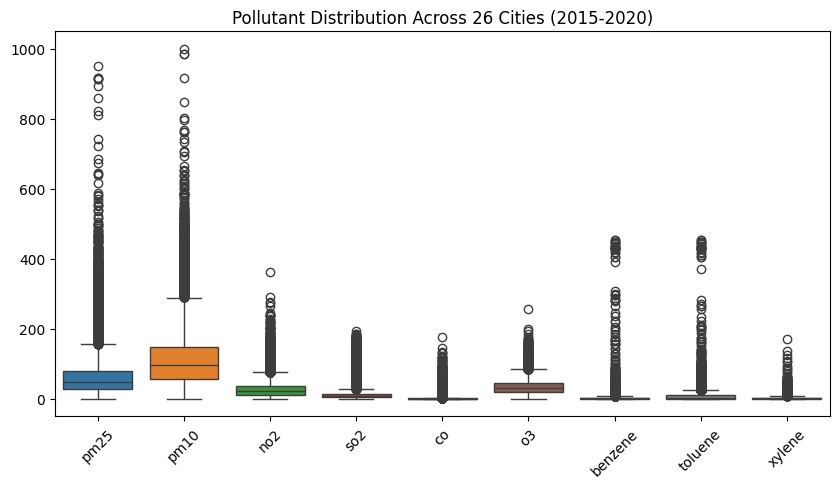

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_hist[['pm25','pm10','no2','so2','co','o3' ,'benzene','toluene','xylene']])
plt.xticks(rotation=45)
plt.title('Pollutant Distribution Across 26 Cities (2015-2020)')
plt.show()

## Analysis 2: Pollutant Correlation

PM2.5 and PM10 show the strongest correlation (r=0.88), confirming they largely share 
common sources (dust, combustion, particulate emissions). This is as expected since PM2.5 is 
a physical subset of PM10.

Benzene and Toluene also correlate strongly (r=0.74), both 
being VOCs from vehicle exhaust and fuel evaporation. SO2 and CO show a moderate link 
(r=0.50), likely from shared industrial/combustion sources. 

Gaseous pollutants like NO2 and O3 don't correlate strongly with particulate matter, suggesting they arise 
from partly independent sources (e.g., photochemical reactions for O3).

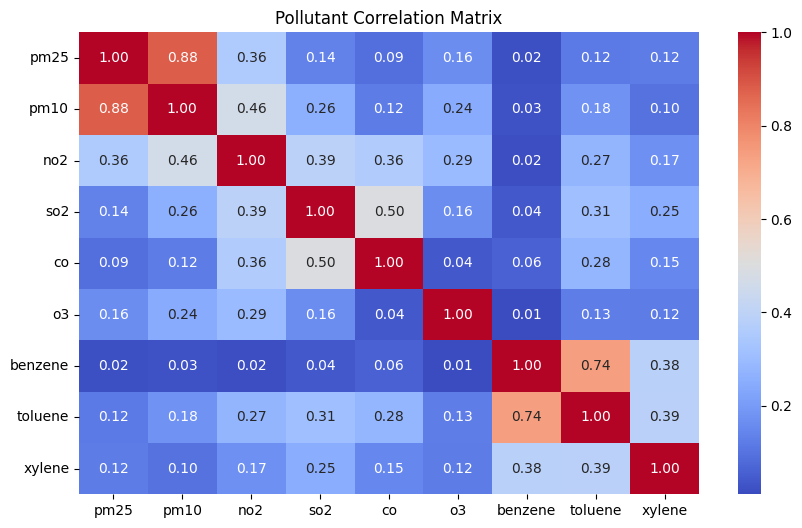

In [17]:
corr = df_hist[['pm25','pm10','no2','so2','co','o3','benzene','toluene','xylene' ]].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pollutant Correlation Matrix')
plt.show()

## Analysis 3: India-wide Yearly Trend

Avg AQI across all 26 cities declined steadily from 2015 to 2020, 
and the share of "Good/Satisfactory" days rose from under 20% to over 55% over the 
same period. "Severe" days also shrank noticeably by 2020.

**Important point:** The 2020 data only covers January–June, which overlaps almost 
entirely with India's COVID-19 lockdown (started late March 2020). The sharp drop in 
2020 likely reflects this temporary halt in traffic/industrial activity rather than a 
sustained long-term improvement.

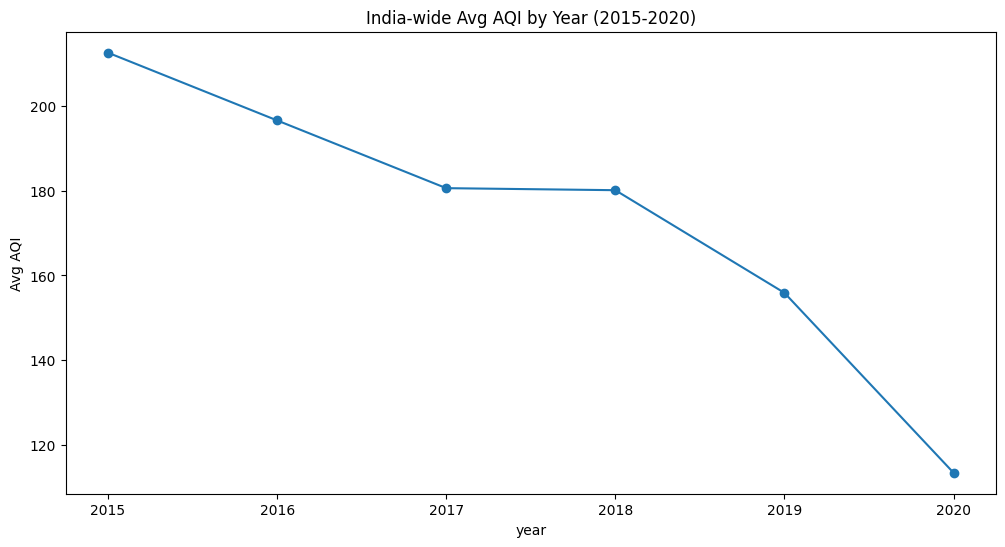

In [18]:
yearly = df_hist.groupby('year')['aqi'].mean()
plt.figure(figsize=(12,6))
yearly.plot(marker='o')
plt.title('India-wide Avg AQI by Year (2015-2020)')
plt.ylabel('Avg AQI')
plt.show()

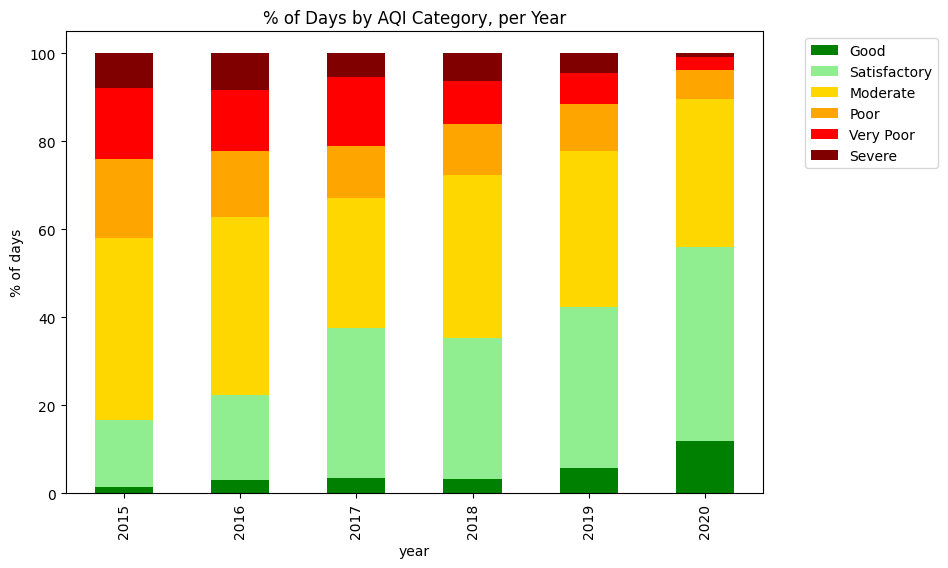

In [19]:
cat_by_year = pd.crosstab(df_hist['year'], df_hist['category'], normalize='index') * 100
cat_by_year = cat_by_year[['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']]
cat_by_year.plot(kind='bar', stacked=True, 
    color=['green','lightgreen','Gold','orange','Red','Maroon'], figsize=(9,6))
plt.title('% of Days by AQI Category, per Year')
plt.ylabel('% of days')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

## Analysis 4: Seasonal & Regional AQI Pattern

All regions follow the same broad seasonal cycle: AQI drops during monsoon months 
(Jun-Sep, when rain washes pollutants out of the air) and spikes in the post-monsoon/
winter period (Oct-Jan, driven by stubble burning, low wind speed, and temperature 
inversion trapping pollutants near the ground).

The West region shows the highest average AQI (peaking ~400 in November) — likely 
driven by Ahmedabad's industrial activity, since the West group here only contains 
3 cities. South and Northeast India stay consistently low (under 150) year-round, 
reflecting cleaner coastal/hill geography and less seasonal swing. Interestingly, the 
North region's average doesn't spike as sharply as West. Moreover this is the old data we might get to see this in the new data.
Delhi's individual winter spike may be getting diluted by other North cities.

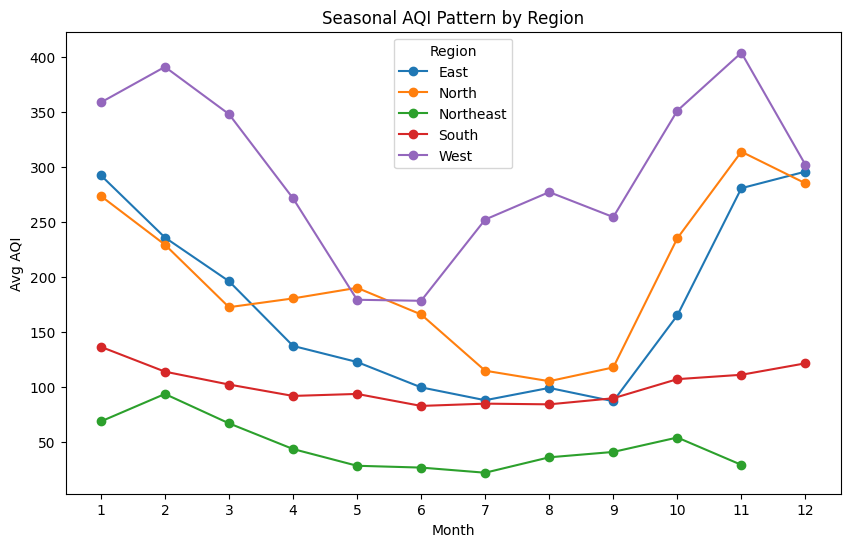

In [20]:
region_season = df_hist.groupby(['region','month'])['aqi'].mean().unstack(level=0)
region_season.plot(kind='line', marker='o', figsize=(10,6))
plt.title('Seasonal AQI Pattern by Region')
plt.xlabel('Month')
plt.ylabel('Avg AQI')
plt.xticks(range(1,13))
plt.legend(title='Region')
plt.show()

## Analysis 5: Weekday vs Weekend AQI

Weekday mean AQI is only marginally higher than weekend mean, and a 
t-test confirms this difference is **not statistically significant** (p=0.17, well 
above the 0.05 threshold).

It suggests that at the city-level, daily-average scale, 
traffic reduction on weekends doesn't meaningfully move the needle on AQI. This likely means non-traffic sources (industry, construction, seasonal/
meteorological factors, agricultural burning) dominate pollution levels more than 
commuter traffic alone.

Weekday avg: 166.2, Weekend avg: 163.6, p=0.1721


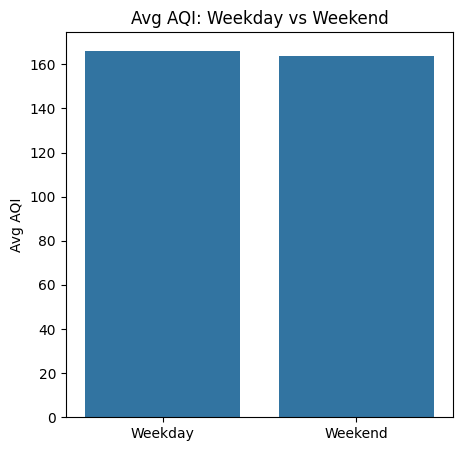

In [21]:
df_hist['is_weekend'] = df_hist['date'].dt.dayofweek >= 5
weekday = df_hist[~df_hist['is_weekend']]['aqi'].dropna()
weekend = df_hist[df_hist['is_weekend']]['aqi'].dropna()

from scipy import stats
t, p = stats.ttest_ind(weekday, weekend)
print(f"Weekday avg: {weekday.mean():.1f}, Weekend avg: {weekend.mean():.1f}, p={p:.4f}")

plt.figure(figsize=(5,5))
sns.barplot(x=['Weekday','Weekend'], y=[weekday.mean(), weekend.mean()])
plt.title('Avg AQI: Weekday vs Weekend')
plt.ylabel('Avg AQI')
plt.show()

## Analysis 6: Diwali Spike (2016-2019)

Across all 4 years studied, AQI spikes sharply in the 1-2 days immediately following 
Diwali, consistent with firecracker emissions. The magnitude and recovery pattern 
varies by year. 2019 showed the sharpest single-day jump (+65%, from 148 to 244) but 
recovered within days, while 2018 stayed elevated for nearly a week before returning 
to pre-Diwali levels.

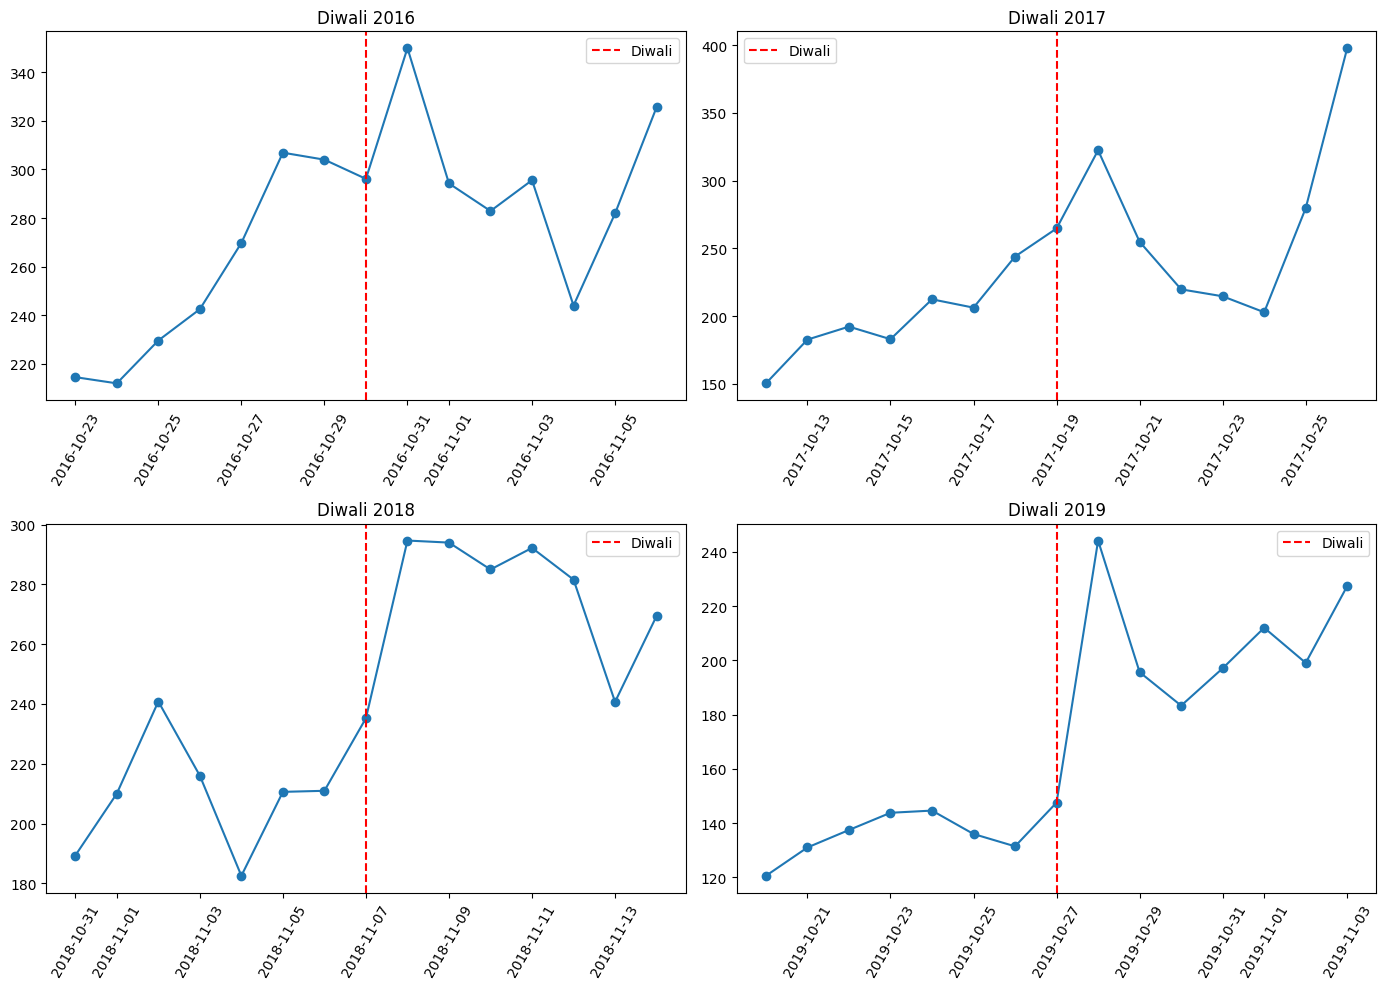

In [22]:
diwali_dates = { 2016:'2016-10-30', 2017:'2017-10-19', 2018:'2018-11-07', 2019:'2019-10-27'}

fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, (year, dd) in zip(axes.flatten(), diwali_dates.items()):
    dd = pd.to_datetime(dd)
    window = df_hist[(df_hist['date']>=dd-pd.Timedelta(days=7)) & (df_hist['date']<=dd+pd.Timedelta(days=7))]
    daily = window.groupby('date')['aqi'].mean()
    ax.plot(daily.index, daily.values, marker='o')
    ax.axvline(dd, color='red', linestyle='--', label='Diwali')
    ax.set_title(f'Diwali {year}')
    ax.tick_params(axis='x', rotation=60)
    ax.legend()
plt.tight_layout()
plt.show()

## Analysis 7: Before (2015-20) vs After (2022-25) Comparison

Both Delhi and Gurugram show measurable air quality improvement between the two 
time periods studied. Delhi's average AQI dropped from 259 to 206 (-20.5%), and 
Gurugram's dropped from 225 to 191 (-15.2%).

**Business relevance:** This is useful to know that the city governments or 
ESG reports can cite this as evidence that 2020-2025 interventions (construction 
regulations, industrial relocation, emission norms) had a measurable effect.

This completely signs that the AQI has been increased post COVID 19 due to lockdowns. The data from 2020 to 2022 is missing as the data is affetced by the lockdowns but after evaluating the change from historical to recent we can say that the exact magnitude should be read as indicative, not precise.


In [23]:
# Looking at the recent AQI data for NCR cities, like Delhi and Gurugram from the unified view
df_u = pd.read_sql("SELECT * FROM v_aqi_unified", engine)
change = df_u[df_u['city_name'].isin(['Delhi','Gurugram'])].groupby(['city_name','source_period'])['aqi_value'].mean().unstack()
change['% change'] = (change['recent'] - change['historical'])/change['historical']*100

change

source_period,historical,recent,% change
city_name,,,
Delhi,259.487744,206.416889,-20.452162
Gurugram,225.123882,190.848214,-15.225247


## Analysis 8: Full NCR Comparison (2022-2025)

**Finding:** Delhi remains the most polluted NCR city (avg AQI ~207), followed closely 
by Greater Noida (~203). Faridabad is the least polluted of the six (~180) — though 
all six cities cluster in a relatively narrow 180-207 range, meaning no NCR city is 
"clean" by comparison.

**Business relevance:** Useful for real-estate/relocation decisions within NCR. The 
gap between best (Faridabad) and worst (Delhi) is only ~13%, so city choice alone 
doesn't solve the problem; NCR-wide policy is needed rather than city-hopping.

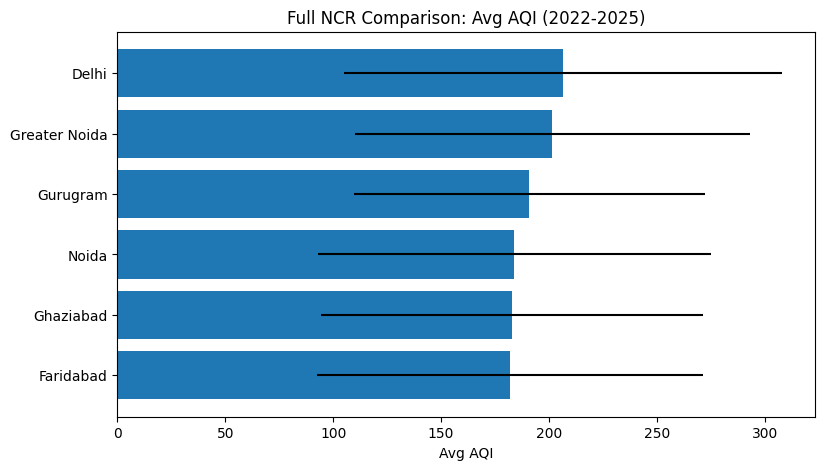

,mean,std
area,,
Delhi,206.416889,101.467030
Greater Noida,201.601959,91.631523
Gurugram,190.848214,81.283032
Noida,183.989324,90.881093
Ghaziabad,183.010676,88.475985
Faridabad,181.926874,89.519609


In [24]:
ncr = ['Delhi','Noida','Greater Noida','Gurugram','Ghaziabad','Faridabad']
df_recent = pd.read_sql(f"SELECT * FROM air_quality_recent WHERE area IN {tuple(ncr)}", engine)

ncr_stats = df_recent.groupby('area')['aqi_value'].agg(['mean','std']).sort_values('mean')
plt.figure(figsize=(9,5))
plt.barh(ncr_stats.index, ncr_stats['mean'], xerr=ncr_stats['std'])
plt.title('Full NCR Comparison: Avg AQI (2022-2025)')
plt.xlabel('Avg AQI')
plt.show()
(ncr_stats.sort_values('mean', ascending=False))

## Analysis 9 : Top cities with Most and Least AQIs

**Findings:** The Most polluted city in India appears to be Byrnihat, Assam. Byrnihat's air quality is severely poor due to heavy industrial concentration, trapped valley geography, and thick vehicular emissions. And the least polluted city in India is Tirunelveli, Tamil Nadu. AI Mode conversation: Tirunelveli, Tamil Nadu. why least AQiTirunelveli, Tamil Nadu. why least AQiTirunelveli regularly records India's best (lowest) Air Quality Index (AQI) values—frequently hovering in the "Good" category between 20 and 45—primarily due to its geography, massive wind energy infrastructure, and low industrial density.

**Business Insights:** This insight can be useful for the people want to settle in the low or no pollution area, which eventually helps in their physical wellbeing.


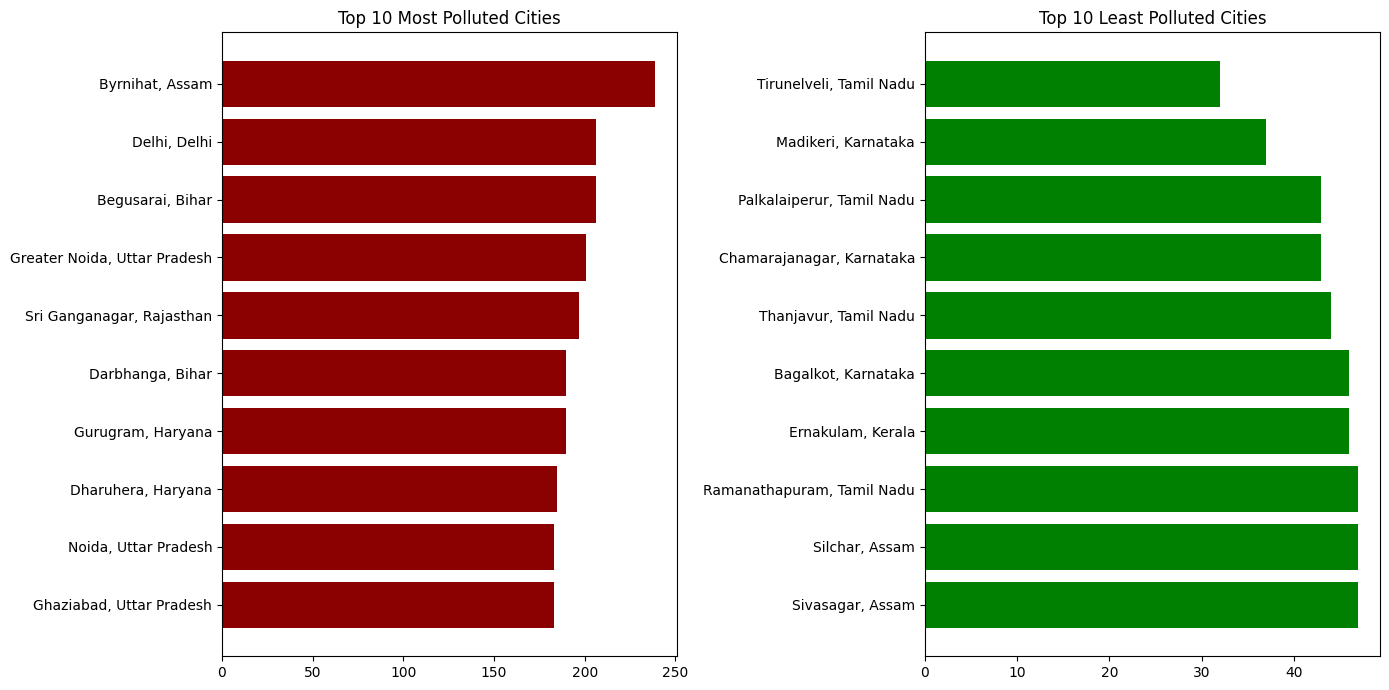

In [25]:
national = pd.read_sql("SELECT area, state, AVG(aqi_value) as avg_aqi FROM air_quality_recent GROUP BY area, state", engine)
top10 = national.sort_values('avg_aqi', ascending=True).tail(10)
bottom10 = national.sort_values('avg_aqi', ascending = False).tail(10)

fig, axes = plt.subplots(1,2, figsize=(14,7))
axes[0].barh(top10['area'] + ', ' + top10['state'], top10['avg_aqi'], color='darkred')
axes[0].set_title('Top 10 Most Polluted Cities')
axes[1].barh(bottom10['area'] + ', ' + bottom10['state'], bottom10['avg_aqi'], color='green')
axes[1].set_title('Top 10 Least Polluted Cities')
plt.tight_layout()
plt.show()

## Analysis 10 : Unhealthy days per city & year (AQI ≥ 201)

**Finding:** Ahmedabad had the highest share of unhealthy days overall, peaking at 
98% in 2018-19 before dropping sharply in 2020. Most cities show a declining trend, 
but Guwahati is the exception — it rose in 2020 while every other city fell.

**Business relevance:** Useful for public health planning — cities with sustained 
high percentages (Ahmedabad, Delhi, Patna) need year-round monitoring, not just 
winter-specific measures.

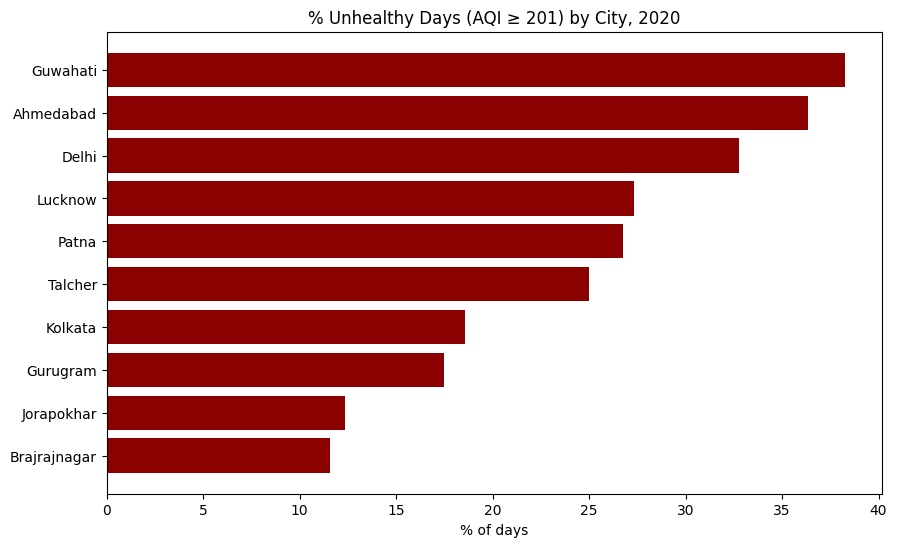

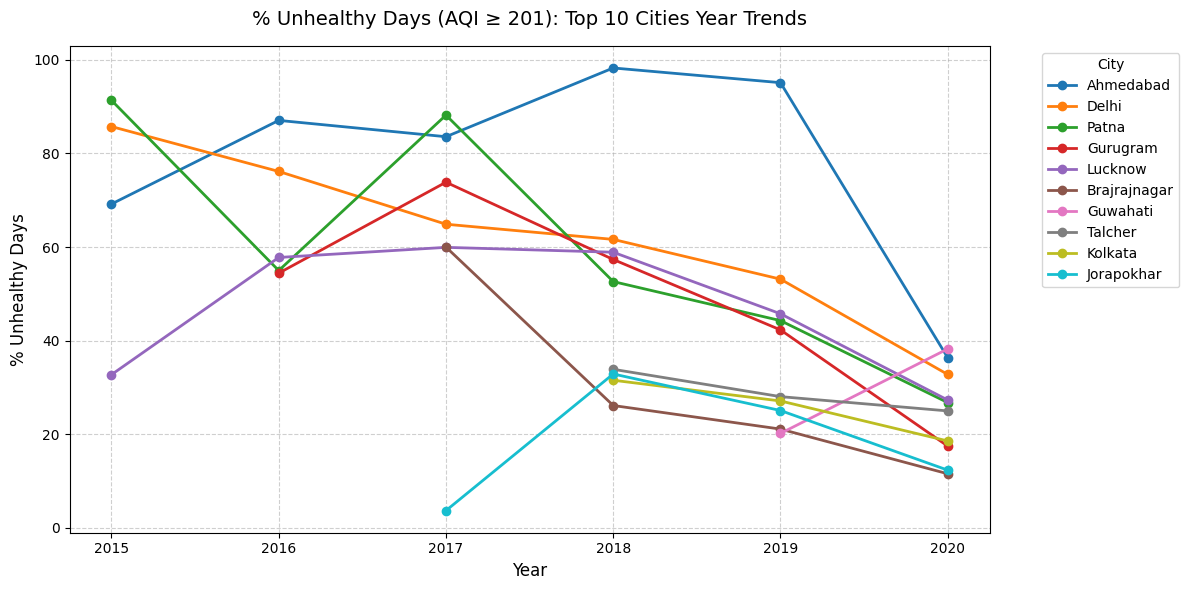

In [26]:
# 1. Define unhealthy days
df_hist['unhealthy'] = df_hist['aqi'] >= 201

# 2. Aggregate by city and year
city_year = df_hist.groupby(['city','year']).agg(
    total_days=('aqi','count'),
    unhealthy_days=('unhealthy','sum')
).reset_index()
city_year['unhealthy_pct'] = (city_year['unhealthy_days'] / city_year['total_days']) * 100

# 3a. Bar chart — latest year available
latest_year = city_year['year'].max()
latest = city_year[city_year['year']==latest_year].sort_values('unhealthy_pct', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(latest['city'], latest['unhealthy_pct'], color='darkred')
plt.title(f'% Unhealthy Days (AQI ≥ 201) by City, {latest_year}')
plt.xlabel('% of days')
plt.gca().invert_yaxis()
plt.show()

# 3b. Line chart — trend over years for top cities

pivot = city_year.pivot(index='city', columns='year', values='unhealthy_pct')

# Filter the pivot matrix to keep only the top 10 cities with the highest average values
top_10_cities = pivot.mean(axis=1).sort_values(ascending=False).head(10).index
pivot_top10 = pivot.loc[top_10_cities]

plt.figure(figsize=(12, 6))

 # Transpose the filtered pivot table so years become the index (X-axis)
pivot_top10.T.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2)

# Customise the chart layout
plt.title('% Unhealthy Days (AQI ≥ 201): Top 10 Cities Year Trends', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('% Unhealthy Days', fontsize=12)  
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
